# Anti-Money Laundering — Logistic Regression L1/L2

### Contextualización Teórica y Matemática
La **Regresión Logística** es un modelo estadístico lineal (GLM) proyectado a través de la función Sigmoide. Modela directamente la probabilidad $P(y=1|X)$ de que una transacción, descrita por su vector de características $X$, pertenezca a la clase delictiva ("Lavado").

Matemáticamente, la función de probabilidad logística se define como:

$$ P(y = 1 | X) = \sigma(\theta^T X) = \frac{1}{1 + e^{-(\theta_0 + \theta_1 x_1 + \dots + \theta_n x_n)}} $$

Donde $\theta$ representa el vector de coeficientes del hiperplano. La optimización busca minimizar la log-pérdida (Cross-Entropy Loss), que en su función de Coste teórica sin regularización es:

$$ J(\theta) = - \frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right] $$

**Regularización L1 (Lasso) vs L2 (Ridge):**
Dado el volumen y potencial ruido en un dataset AML inmenso, para prevenir anomalías o *overfitting* de pesos sobre variables correlacionadas, este notebook explora sistemáticamente las penalizaciones combinadas (*shrinkage penalties*) al costo iterativo, controladas por el parámetro de castigo $C = \frac{1}{\lambda}$ y penalidades:

- **Penalización L1 (Lasso - Norma Manhattan):** Adiciona la suma de la magnitud absoluta de los coeficientes. Tiende matemáticamente a empujar pesos irrelevantes y redundantes **exactamente a cero absoluto**, ejecutando en efecto una selección de variables subyacente.
  $$ J_{L1}(\theta) = J(\theta) + \frac{1}{C} \sum_{j=1}^{n} |\theta_j| $$

- **Penalización L2 (Ridge - Norma Euclidiana):** Adiciona los pesos al cuadrado. Reprime la inflación aritmética excesiva de los estimadores a través del "shrinkage" continuo hacia cero para limitar la intercolinealidad estadística sin eliminar variables.
  $$ J_{L2}(\theta) = J(\theta) + \frac{1}{2C} \sum_{j=1}^{n} \theta_j^2 $$



## Sección 1 · Imports y Configuración


In [2]:
!pip install deap optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 70.7 MB/s eta 0:00:00


In [3]:
import warnings, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy.stats import loguniform, randint

from sklearn.base            import BaseEstimator, ClassifierMixin
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.model_selection import (
    TimeSeriesSplit, GridSearchCV, RandomizedSearchCV, cross_val_score
)
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve, auc, f1_score, roc_auc_score
)

from imblearn.pipeline      import Pipeline
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.base          import BaseSampler

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from deap import base, creator, tools, algorithms

warnings.filterwarnings("ignore")
sns.set_theme(style='ticks', context='paper', font_scale=1.2, palette='Set1')

# ── Constantes globales ────────────────────────────────────────────────────────
RANDOM_STATE    = 42
N_SPLITS        = 3      # TimeSeriesSplit folds (cronológico, nunca KFold aleatorio)
N_ITER_RANDOM   = 20     # Random Search: iteraciones totales
N_TRIALS_OPTUNA = 30     # Optuna: trials totales
POP_SIZE        = 10     # DEAP: tamaño de la población
N_GEN           = 5      # DEAP: número de generaciones
BASE_PATH       = '/content/drive/MyDrive/Datasets/Final Project/Processed/'

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

## Sección 2 · Clases Auxiliares


In [4]:
# Check current GPU setup
!nvidia-smi

# Uninstall potentially conflicting CPU-based CuPy or other old CuPy versions
# This helps ensure a clean install of the CUDA-compatible CuPy required by cuML
!pip uninstall -y cupy cupy-cuda11x 2>/dev/null

# Install cuDF (often a dependency for cuML) and cuML specific to CUDA 12.x
# The --extra-index-url flags are crucial to find the NVIDIA-provided wheels.
!pip install --extra-index-url=https://pypi.nvidia.com --extra-index-url=https://pypi.ngc.nvidia.com cudf-cu12 cuml-cu12 -q

# Now import the LogisticRegression from cuml
from cuml.linear_model import LogisticRegression as cuLR

Mon May 18 19:24:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   43C    P8             13W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [14]:
class IdentitySampler(BaseSampler):
    """Bypass: no aplica ningún oversampling, pasa los datos tal cual."""
    _sampling_type         = "bypass"
    _parameter_constraints = {}

    def _fit_resample(self, X, y):
        return X, y

    def __repr__(self):
        return "IdentitySampler()"


from cuml.linear_model import LogisticRegression as cuLR

class DynamicBalanceLR(BaseEstimator, ClassifierMixin):
    def __init__(self, C=1.0, penalty='l2', max_iter=200,
                 use_balanced_weight=False, random_state=RANDOM_STATE):
        self.C                   = C
        self.penalty             = penalty
        self.max_iter            = max_iter
        self.use_balanced_weight = use_balanced_weight
        self.random_state        = random_state
        self.model_              = None

    def fit(self, X, y, **kwargs):
        # cuML únicamente soporta solver='qn' (para L1 y L2)
        cw = 'balanced' if self.use_balanced_weight else None
        self.model_ = cuLR(
            C            = self.C,
            penalty      = self.penalty,
            solver       = 'qn',          # único solver disponible en cuML
            max_iter     = self.max_iter,
            class_weight = cw,
        )
        self.model_.fit(X, y)
        return self

    def predict(self, X):       return self.model_.predict(X)
    def predict_proba(self, X): return self.model_.predict_proba(X)

    @property
    def coef_(self):
        return self.model_.coef_ if self.model_ is not None else None

    @property
    def n_nonzero_coef_(self):
        if self.model_ is None:
            return None
        return int(np.sum(np.abs(self.model_.coef_[0]) > 1e-6))

## Sección 3 · Carga de Datos


In [15]:
from google.colab import drive
drive.mount('/content/drive')

X_train = pd.read_parquet(f'{BASE_PATH}X_train.parquet')
X_test  = pd.read_parquet(f'{BASE_PATH}X_test.parquet')
y_train = pd.read_parquet(f'{BASE_PATH}y_train.parquet')['Is Laundering']
y_test  = pd.read_parquet(f'{BASE_PATH}y_test.parquet')['Is Laundering']

print(f"X_train : {X_train.shape} | y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}  | y_test  : {y_test.shape}")
print(f"Prevalencia Lavado — Train: {y_train.mean():.4%} | Test: {y_test.mean():.4%}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
X_train : (4062668, 45) | y_train : (4062668,)
X_test  : (1015668, 45)  | y_test  : (1015668,)
Prevalencia Lavado — Train: 0.0832% | Test: 0.1770%


## Sección 4 · Configuraciones Compartidas


In [16]:
TSCV = TimeSeriesSplit(n_splits=N_SPLITS)

BALANCE_CONFIGS = [
    {'id': 0, 'name': 'Sin balanceo',             'use_bw': False},
    {'id': 1, 'name': 'SMOTE',                     'use_bw': False},
    {'id': 2, 'name': 'ADASYN',                    'use_bw': False},
    {'id': 3, 'name': "class_weight='balanced'",   'use_bw': True },
]

def get_fresh_sampler(bal_id):
    """Retorna una instancia nueva del sampler para evitar estado residual."""
    if bal_id == 1: return SMOTE(random_state=RANDOM_STATE)
    if bal_id == 2: return ADASYN(random_state=RANDOM_STATE)
    return IdentitySampler()

# ── Espacio Grid Search ────────────────────────────────────────────────────────
# 5×2×2 = 20 combinaciones × 4 estrategias de balanceo = 80 configs
# 80 × 3 folds = 240 entrenamientos LR
PARAM_GRID = {
    'clf__C'       : [0.001, 0.01, 0.1, 1.0, 10.0],
    'clf__penalty' : ['l1', 'l2'],
    'clf__max_iter': [200, 500],
}

# ── Espacio Random Search: distribuciones continuas ───────────────────────────
PARAM_DIST = {
    'clf__C'       : loguniform(1e-4, 1e2),    # log-uniforme: igual prob. por décimo
    'clf__penalty' : ['l1', 'l2'],
    'clf__max_iter': randint(100, 1001),
}

RESULTS = {}  # Diccionario global de resultados

In [17]:
# ── Helpers de convergencia ────────────────────────────────────────────────────
def converged_optuna(study, patience=10):
    """True si el mejor valor acumulado no mejoró en los últimos `patience` trials."""
    vals = [t.value for t in study.trials if t.value is not None]
    if len(vals) < patience:
        return False
    best = [max(vals[:i + 1]) for i in range(len(vals))]
    return len(set(best[-patience:])) == 1


def converged_deap(logbook, patience=2):
    """True si el F1 máximo no mejoró en las últimas `patience` generaciones."""
    maxes = logbook.select('max')
    if len(maxes) <= patience:
        return False
    return maxes[-1] == maxes[-(patience + 1)]


# ── Helpers DEAP: cromosoma de 4 genes ───────────────────────────────────────
# Gen 0: balance_strategy  (int   0–3)
# Gen 1: C_exp             (float -4.0 – 2.0)  →  C = 10^C_exp  (escala log)
# Gen 2: penalty           (int   0=l1, 1=l2)
# Gen 3: max_iter          (int   100–1000)
#
# C se codifica como su exponente en base 10 para que el operador de cruce y
# mutación en ℝ actúe de forma log-uniforme, equivalente a loguniform en
# Random Search y suggest_float(..., log=True) en Optuna.

def decode_individual(ind):
    """Traduce los 4 genes del individuo a parámetros interpretables."""
    bal_id   = int(ind[0])
    C        = 10 ** float(ind[1])               # decodificación log-escala
    penalty  = 'l1' if int(ind[2]) == 0 else 'l2'
    max_iter = int(ind[3])
    return bal_id, C, penalty, max_iter


def mutate_individual(individual, indpb):
    """Mutación personalizada con restricciones de rango por gen."""
    if random.random() < indpb: individual[0] = random.randint(0, 3)
    if random.random() < indpb: individual[1] = random.uniform(-4.0, 2.0)
    if random.random() < indpb: individual[2] = random.randint(0, 1)
    if random.random() < indpb: individual[3] = random.randint(100, 1000)
    return individual,


def _init_deap_toolbox(evaluate_fn, X_train, y_train):
    """Registra los operadores DEAP y retorna el toolbox configurado."""
    if hasattr(creator, 'FitnessMax'): del creator.FitnessMax
    if hasattr(creator, 'Individual'): del creator.Individual
    creator.create('FitnessMax', base.Fitness, weights=(1.0,))
    creator.create('Individual', list, fitness=creator.FitnessMax)

    cv      = TimeSeriesSplit(n_splits=N_SPLITS)
    toolbox = base.Toolbox()
    toolbox.register('attr_bal',     random.randint,  0,    3)
    toolbox.register('attr_C_exp',   random.uniform,  -4.0, 2.0)
    toolbox.register('attr_penalty', random.randint,  0,    1)
    toolbox.register('attr_iter',    random.randint,  100,  1000)
    toolbox.register(
        'individual', tools.initCycle, creator.Individual,
        (toolbox.attr_bal, toolbox.attr_C_exp,
         toolbox.attr_penalty, toolbox.attr_iter), n=1
    )
    toolbox.register('population', tools.initRepeat, list, toolbox.individual)
    toolbox.register('evaluate', evaluate_fn, X=X_train, y=y_train, cv=cv)
    toolbox.register('mate',   tools.cxTwoPoint)
    toolbox.register('mutate', mutate_individual, indpb=0.25)
    toolbox.register('select', tools.selTournament, tournsize=3)
    return toolbox


def _run_deap(toolbox, pop_size, n_gen):
    """Ejecuta eaSimple y retorna (best_ind, logbook, elapsed_min)."""
    pop   = toolbox.population(n=pop_size)
    hof   = tools.HallOfFame(1)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register('avg', np.mean)
    stats.register('max', np.max)

    t0 = time.time()
    pop, logbook = algorithms.eaSimple(
        pop, toolbox, cxpb=0.5, mutpb=0.2,
        ngen=n_gen, stats=stats, halloffame=hof, verbose=True
    )
    elapsed = (time.time() - t0) / 60
    return hof[0], logbook, elapsed


# ── Construcción y predicción del modelo final ────────────────────────────────
def build_final_model(spec, X_train, y_train):
    """
    Reconstruye y entrena el pipeline final en todo X_train.
    spec = {'bal_id': int, 'C': float, 'penalty': str, 'max_iter': int}
    """
    sampler = get_fresh_sampler(spec['bal_id'])
    use_bw  = BALANCE_CONFIGS[spec['bal_id']]['use_bw']
    pipe = Pipeline([
        ('scaler',  StandardScaler()),
        ('sampler', sampler),
        ('clf',     DynamicBalanceLR(
                        C                   = spec['C'],
                        penalty             = spec['penalty'],
                        max_iter            = spec['max_iter'],
                        use_balanced_weight = use_bw)),
    ])
    pipe.fit(X_train, y_train)
    return pipe


def predict_final(model, X_test):
    """Genera (y_pred, y_proba) del pipeline final."""
    return model.predict(X_test), model.predict_proba(X_test)[:, 1]


def timeit_inference(pipe, X, reps=50):
    """Tiempo medio de predicción sobre X (en segundos)."""
    times = []
    for _ in range(reps):
        t0 = time.perf_counter()
        pipe.predict(X)
        times.append(time.perf_counter() - t0)
    return np.mean(times)

## Sección 5 · Logistic Regression — Grid Search


In [18]:
def run_grid_search_lr(X_train, y_train):
    n_combos = 1
    for v in PARAM_GRID.values():
        n_combos *= len(v)

    print(f"{'═'*62}")
    print(f" Grid Search — Logistic Regression")
    print(f"{'═'*62}")
    print(f" Combinaciones por estrategia : {n_combos}")
    print(f" Configs totales evaluadas    : {n_combos * len(BALANCE_CONFIGS)}")
    print(f" Fits totales (× {N_SPLITS} folds)     : {n_combos * len(BALANCE_CONFIGS) * N_SPLITS}\n")

    best_f1, best_spec, best_bal_name = -1, None, None
    t0 = time.time()

    for bal_cfg in BALANCE_CONFIGS:
        sampler = get_fresh_sampler(bal_cfg['id'])
        pipe    = Pipeline([
            ('scaler',  StandardScaler()),
            ('sampler', sampler),
            ('clf',     DynamicBalanceLR(use_balanced_weight=bal_cfg['use_bw'])),
        ])
        search = GridSearchCV(pipe, PARAM_GRID, cv=TSCV,
                              scoring='f1', n_jobs=4, refit=False)
        search.fit(X_train, y_train)

        score = search.best_score_
        print(f"  [{bal_cfg['name']:35s}]  F1 CV = {score:.4f}")

        if score > best_f1:
            best_f1       = score
            best_bal_name = bal_cfg['name']
            p             = search.best_params_
            best_spec     = {
                'bal_id'  : bal_cfg['id'],
                'C'       : p['clf__C'],
                'penalty' : p['clf__penalty'],
                'max_iter': p['clf__max_iter'],
            }

    elapsed = (time.time() - t0) / 60
    n_evals = n_combos * len(BALANCE_CONFIGS)

    print(f"\n  ✓ Mejor F1 (CV) : {best_f1:.4f}  |  Balanceo : {best_bal_name}")
    print(f"  ✓ Tiempo total  : {elapsed:.1f} min  |  Evaluaciones : {n_evals}")

    RESULTS['lr_grid'] = {
        'label'       : 'Logistic Regression',
        'method'      : 'Grid Search',
        'best_f1'     : round(best_f1, 4),
        'time_min'    : round(elapsed, 2),
        'n_evals'     : n_evals,
        'converged'   : 'N/A',
        'best_balance': best_bal_name,
        'spec'        : best_spec,
    }
    return RESULTS['lr_grid']


result_grid = run_grid_search_lr(X_train, y_train)

══════════════════════════════════════════════════════════════
 Grid Search — Logistic Regression
══════════════════════════════════════════════════════════════
 Combinaciones por estrategia : 20
 Configs totales evaluadas    : 80
 Fits totales (× 3 folds)     : 240

  [Sin balanceo                       ]  F1 CV = 0.0012
  [SMOTE                              ]  F1 CV = 0.0309
  [ADASYN                             ]  F1 CV = 0.0304
  [class_weight='balanced'            ]  F1 CV = 0.0272

  ✓ Mejor F1 (CV) : 0.0309  |  Balanceo : SMOTE
  ✓ Tiempo total  : 20.6 min  |  Evaluaciones : 80


## Sección 6 · Logistic Regression — Random Search


In [19]:
def run_random_search_lr(X_train, y_train, n_iter=N_ITER_RANDOM):
    print(f"{'═'*62}")
    print(f" Random Search — Logistic Regression")
    print(f"{'═'*62}")
    print(f" Iteraciones por estrategia : {n_iter}")
    print(f" Configs totales evaluadas  : {n_iter * len(BALANCE_CONFIGS)}\n")

    best_f1, best_spec, best_bal_name = -1, None, None
    t0 = time.time()

    for bal_cfg in BALANCE_CONFIGS:
        sampler = get_fresh_sampler(bal_cfg['id'])
        pipe    = Pipeline([
            ('scaler',  StandardScaler()),
            ('sampler', sampler),
            ('clf',     DynamicBalanceLR(use_balanced_weight=bal_cfg['use_bw'])),
        ])
        search = RandomizedSearchCV(pipe, PARAM_DIST, n_iter=n_iter, cv=TSCV,
                                    scoring='f1', n_jobs=4, refit=False,
                                    random_state=RANDOM_STATE)
        search.fit(X_train, y_train)

        score = search.best_score_
        print(f"  [{bal_cfg['name']:35s}]  F1 CV = {score:.4f}")

        if score > best_f1:
            best_f1       = score
            best_bal_name = bal_cfg['name']
            p             = search.best_params_
            best_spec     = {
                'bal_id'  : bal_cfg['id'],
                'C'       : p['clf__C'],
                'penalty' : p['clf__penalty'],
                'max_iter': p['clf__max_iter'],
            }

    elapsed = (time.time() - t0) / 60
    n_evals = n_iter * len(BALANCE_CONFIGS)

    print(f"\n  ✓ Mejor F1 (CV) : {best_f1:.4f}  |  Balanceo : {best_bal_name}")
    print(f"  ✓ Tiempo total  : {elapsed:.1f} min  |  Evaluaciones : {n_evals}")

    RESULTS['lr_random'] = {
        'label'       : 'Logistic Regression',
        'method'      : 'Random Search',
        'best_f1'     : round(best_f1, 4),
        'time_min'    : round(elapsed, 2),
        'n_evals'     : n_evals,
        'converged'   : 'N/A',
        'best_balance': best_bal_name,
        'spec'        : best_spec,
    }
    return RESULTS['lr_random']


result_random = run_random_search_lr(X_train, y_train)

══════════════════════════════════════════════════════════════
 Random Search — Logistic Regression
══════════════════════════════════════════════════════════════
 Iteraciones por estrategia : 20
 Configs totales evaluadas  : 80

  [Sin balanceo                       ]  F1 CV = 0.0012
  [SMOTE                              ]  F1 CV = 0.0309
  [ADASYN                             ]  F1 CV = 0.0304
  [class_weight='balanced'            ]  F1 CV = 0.0272

  ✓ Mejor F1 (CV) : 0.0309  |  Balanceo : SMOTE
  ✓ Tiempo total  : 24.8 min  |  Evaluaciones : 80


## Sección 7 · Logistic Regression — Bayesiano (Optuna / TPE)


In [20]:
def run_optuna_lr(X_train, y_train, n_trials=N_TRIALS_OPTUNA):
    print(f"{'═'*62}")
    print(f" Bayesiano (Optuna/TPE) — Logistic Regression")
    print(f"{'═'*62}")
    print(f" Trials : {n_trials}  |  CV : {N_SPLITS}-fold TimeSeriesSplit\n")

    def objective(trial):
        bal_id   = trial.suggest_int('balance_strategy', 0, 3)
        C        = trial.suggest_float('C', 1e-4, 1e2, log=True)   # log-scale
        penalty  = trial.suggest_categorical('penalty', ['l1', 'l2'])
        max_iter = trial.suggest_int('max_iter', 100, 1000)

        bal_cfg = BALANCE_CONFIGS[bal_id]
        sampler = get_fresh_sampler(bal_id)
        pipe    = Pipeline([
            ('scaler',  StandardScaler()),
            ('sampler', sampler),
            ('clf',     DynamicBalanceLR(
                            C                   = C,
                            penalty             = penalty,
                            max_iter            = max_iter,
                            use_balanced_weight = bal_cfg['use_bw'])),
        ])
        scores = cross_val_score(pipe, X_train, y_train, cv=TSCV,
                                 scoring='f1', n_jobs=4, error_score=0.0)
        return scores.mean()

    t0    = time.time()
    study = optuna.create_study(
        direction = 'maximize',
        sampler   = TPESampler(seed=RANDOM_STATE),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    elapsed = (time.time() - t0) / 60

    best    = study.best_trial
    bal_cfg = BALANCE_CONFIGS[best.params['balance_strategy']]
    conv    = converged_optuna(study)

    print(f"\n  ✓ Mejor F1 (CV) : {best.value:.4f}  |  Balanceo : {bal_cfg['name']}")
    print(f"  ✓ Tiempo total  : {elapsed:.1f} min  |  ¿Convergió? : {'Sí' if conv else 'No'}")

    RESULTS['lr_optuna'] = {
        'label'       : 'Logistic Regression',
        'method'      : 'Bayesiano',
        'best_f1'     : round(best.value, 4),
        'time_min'    : round(elapsed, 2),
        'n_evals'     : n_trials,
        'converged'   : 'Sí' if conv else 'No',
        'best_balance': bal_cfg['name'],
        'spec'        : {
            'bal_id'  : best.params['balance_strategy'],
            'C'       : best.params['C'],
            'penalty' : best.params['penalty'],
            'max_iter': best.params['max_iter'],
        },
        'study': study,
    }
    return RESULTS['lr_optuna']


result_optuna = run_optuna_lr(X_train, y_train)

══════════════════════════════════════════════════════════════
 Bayesiano (Optuna/TPE) — Logistic Regression
══════════════════════════════════════════════════════════════
 Trials : 30  |  CV : 3-fold TimeSeriesSplit



  0%|          | 0/30 [00:00<?, ?it/s]


  ✓ Mejor F1 (CV) : 0.0309  |  Balanceo : SMOTE
  ✓ Tiempo total  : 22.5 min  |  ¿Convergió? : Sí


## Sección 8 · Logistic Regression — DEAP (Algoritmo Genético)


In [21]:
def evaluate_individual_lr(individual, X, y, cv):
    bal_id, C, penalty, max_iter = decode_individual(individual)
    bal_cfg = BALANCE_CONFIGS[bal_id]
    sampler = get_fresh_sampler(bal_id)
    pipe    = Pipeline([
        ('scaler',  StandardScaler()),
        ('sampler', sampler),
        ('clf',     DynamicBalanceLR(
                        C                   = C,
                        penalty             = penalty,
                        max_iter            = max_iter,
                        use_balanced_weight = bal_cfg['use_bw'])),
    ])
    scores = cross_val_score(pipe, X, y, cv=cv,
                             scoring='f1', n_jobs=4, error_score=0.0)
    return (scores.mean(),)


def run_deap_lr(X_train, y_train, pop_size=POP_SIZE, n_gen=N_GEN):
    print(f"{'═'*62}")
    print(f" DEAP (Genético) — Logistic Regression")
    print(f"{'═'*62}")
    print(f" Población : {pop_size}  |  Generaciones : {n_gen}  |  CV : {N_SPLITS}-fold\n")

    toolbox = _init_deap_toolbox(evaluate_individual_lr, X_train, y_train)
    best_ind, logbook, elapsed = _run_deap(toolbox, pop_size, n_gen)

    bal_id, C, penalty, max_iter = decode_individual(best_ind)
    bal_name = BALANCE_CONFIGS[bal_id]['name']
    conv     = converged_deap(logbook)
    n_evals  = pop_size * n_gen

    print(f"\n  ✓ Mejor F1 (CV) : {best_ind.fitness.values[0]:.4f}  |  Balanceo : {bal_name}")
    print(f"  ✓ Tiempo total  : {elapsed:.1f} min  |  ¿Convergió? : {'Sí' if conv else 'No'}")

    RESULTS['lr_deap'] = {
        'label'       : 'Logistic Regression',
        'method'      : 'DEAP (Genético)',
        'best_f1'     : round(best_ind.fitness.values[0], 4),
        'time_min'    : round(elapsed, 2),
        'n_evals'     : n_evals,
        'converged'   : 'Sí' if conv else 'No',
        'best_balance': bal_name,
        'spec'        : {
            'bal_id'  : bal_id,
            'C'       : C,
            'penalty' : penalty,
            'max_iter': max_iter,
        },
        'logbook': logbook,
    }
    return RESULTS['lr_deap']


result_deap = run_deap_lr(X_train, y_train)

══════════════════════════════════════════════════════════════
 DEAP (Genético) — Logistic Regression
══════════════════════════════════════════════════════════════
 Población : 10  |  Generaciones : 5  |  CV : 3-fold

gen	nevals	avg     	max      
0  	10    	0.026959	0.0308421
1  	8     	0.0306957	0.0308577
2  	6     	0.0299886	0.0308673
3  	10    	0.0277975	0.0308767
4  	6     	0.0307985	0.0308757
5  	6     	0.0306597	0.0308707

  ✓ Mejor F1 (CV) : 0.0309  |  Balanceo : SMOTE
  ✓ Tiempo total  : 26.0 min  |  ¿Convergió? : No


## Sección 9 · Optimización Computacional — Curva de Regularización y Sparsidad L1 vs L2


Generando curva de regularización (F1-CV vs C)...
  ✓ C óptimo L1 (CV) : 1.27427  →  F1 = 0.0309
  ✓ C óptimo L2 (CV) : 5.45559  →  F1 = 0.0309


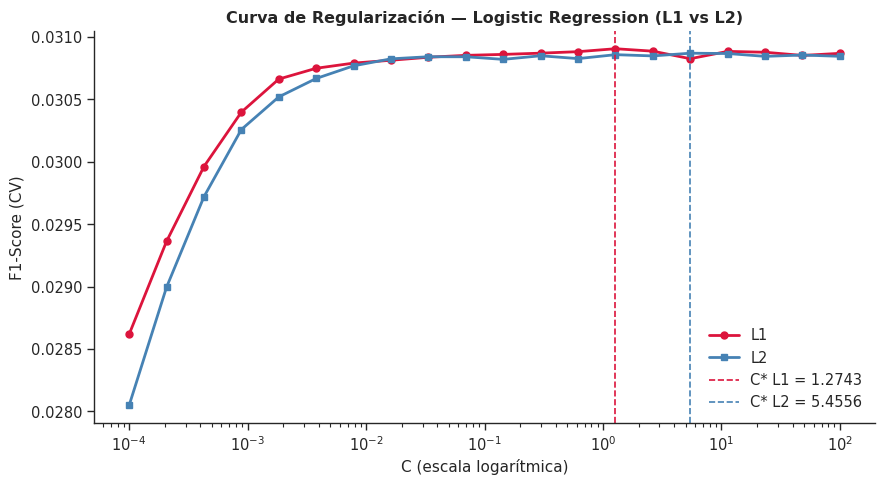

In [22]:
# ── 9.1 Curva de regularización: F1-CV vs C para L1 y L2 ─────────────────────
print("Generando curva de regularización (F1-CV vs C)...")
C_values    = np.logspace(-4, 2, 20)
best_key_r9 = max(RESULTS, key=lambda k: RESULTS[k]['best_f1'])
best_bal_id = RESULTS[best_key_r9]['spec']['bal_id']
use_bw_reg  = BALANCE_CONFIGS[best_bal_id]['use_bw']

f1_l1_cv, f1_l2_cv = [], []

for C_val in C_values:
    for pen, f1_list in [('l1', f1_l1_cv), ('l2', f1_l2_cv)]:
        sampler_i = get_fresh_sampler(best_bal_id)
        pipe_i    = Pipeline([
            ('scaler',  StandardScaler()),
            ('sampler', sampler_i),
            ('clf',     DynamicBalanceLR(
                            C                   = C_val,
                            penalty             = pen,
                            max_iter            = 500,
                            use_balanced_weight = use_bw_reg)),
        ])
        score = cross_val_score(pipe_i, X_train, y_train, cv=TSCV,
                                scoring='f1', n_jobs=4, error_score=0.0).mean()
        f1_list.append(score)

best_C_l1 = C_values[np.argmax(f1_l1_cv)]
best_C_l2 = C_values[np.argmax(f1_l2_cv)]
print(f"  ✓ C óptimo L1 (CV) : {best_C_l1:.5f}  →  F1 = {max(f1_l1_cv):.4f}")
print(f"  ✓ C óptimo L2 (CV) : {best_C_l2:.5f}  →  F1 = {max(f1_l2_cv):.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(C_values, f1_l1_cv, 'o-', color='crimson',   lw=2, ms=5, label='L1')
ax.semilogx(C_values, f1_l2_cv, 's-', color='steelblue', lw=2, ms=5, label='L2')
ax.axvline(best_C_l1, color='crimson',   linestyle='--', lw=1.2,
           label=f'C* L1 = {best_C_l1:.4f}')
ax.axvline(best_C_l2, color='steelblue', linestyle='--', lw=1.2,
           label=f'C* L2 = {best_C_l2:.4f}')
ax.set_xlabel('C (escala logarítmica)', fontsize=11)
ax.set_ylabel('F1-Score (CV)', fontsize=11)
ax.set_title('Curva de Regularización — Logistic Regression (L1 vs L2)', fontweight='bold')
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f'{BASE_PATH}regularization_curve_lr.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretación de la Curva de Regularización

Este gráfico muestra que valores muy pequeños de $C$ provocan un fuerte subajuste (*underfitting*) que reduce drásticamente el rendimiento del modelo, el cual logra estabilizarse a partir de $C = 10^{-2}$. El rendimiento óptimo (F1-Score $\approx 0.031$) se alcanza en $C^* \approx 1.27$ para la penalización **L1** y en $C^* \approx 5.46$ para **L2**, demostrando que ambos métodos se comportan de manera casi idéntica en su punto máximo, aunque **L1** tolera mejor la regularización extrema en valores muy bajos de $C$.

In [23]:
# ── 9.2 Entrenar L1 y L2 con su C óptimo de CV ───────────────────────────────
spec_l1 = {'bal_id': best_bal_id, 'C': best_C_l1, 'penalty': 'l1', 'max_iter': 500}
spec_l2 = {'bal_id': best_bal_id, 'C': best_C_l2, 'penalty': 'l2', 'max_iter': 500}

print("\nEntrenando modelos L1 y L2 con C* de la curva de regularización...")
pipe_l1 = build_final_model(spec_l1, X_train, y_train)
pipe_l2 = build_final_model(spec_l2, X_train, y_train)

lr_l1 = pipe_l1.named_steps['clf']
lr_l2 = pipe_l2.named_steps['clf']

n_features  = X_train.shape[1]
nonzero_l1  = lr_l1.n_nonzero_coef_
nonzero_l2  = lr_l2.n_nonzero_coef_

t_l1 = timeit_inference(pipe_l1, X_test, reps=50)
t_l2 = timeit_inference(pipe_l2, X_test, reps=50)

f1_l1 = f1_score(y_test, pipe_l1.predict(X_test))
f1_l2 = f1_score(y_test, pipe_l2.predict(X_test))

print(f"\n{'═'*62}")
print(f" Comparativa: L1 (liblinear) vs L2 (lbfgs)")
print(f"{'═'*62}")
print(f"{'Métrica':<32} {'L1':>12} {'L2':>12}")
print(f"{'─'*56}")
print(f"{'Features totales':<32} {n_features:>12d} {n_features:>12d}")
print(f"{'Coef. no nulos (|w| > 1e-6)':<32} {nonzero_l1:>12d} {nonzero_l2:>12d}")
print(f"{'Sparsidad (%)':<32} {100*(1-nonzero_l1/n_features):>11.1f}% "
      f"{100*(1-nonzero_l2/n_features):>11.1f}%")
print(f"{'Tiempo inferencia (ms)':<32} {t_l1*1000:>12.3f} {t_l2*1000:>12.3f}")
print(f"{'F1-Score (test)':<32} {f1_l1:>12.4f} {f1_l2:>12.4f}")
print(f"{'═'*62}")


Entrenando modelos L1 y L2 con C* de la curva de regularización...

══════════════════════════════════════════════════════════════
 Comparativa: L1 (liblinear) vs L2 (lbfgs)
══════════════════════════════════════════════════════════════
Métrica                                    L1           L2
────────────────────────────────────────────────────────
Features totales                           45           45
Coef. no nulos (|w| > 1e-6)                45           45
Sparsidad (%)                            0.0%         0.0%
Tiempo inferencia (ms)                433.406      428.344
F1-Score (test)                        0.0640       0.0640
══════════════════════════════════════════════════════════════


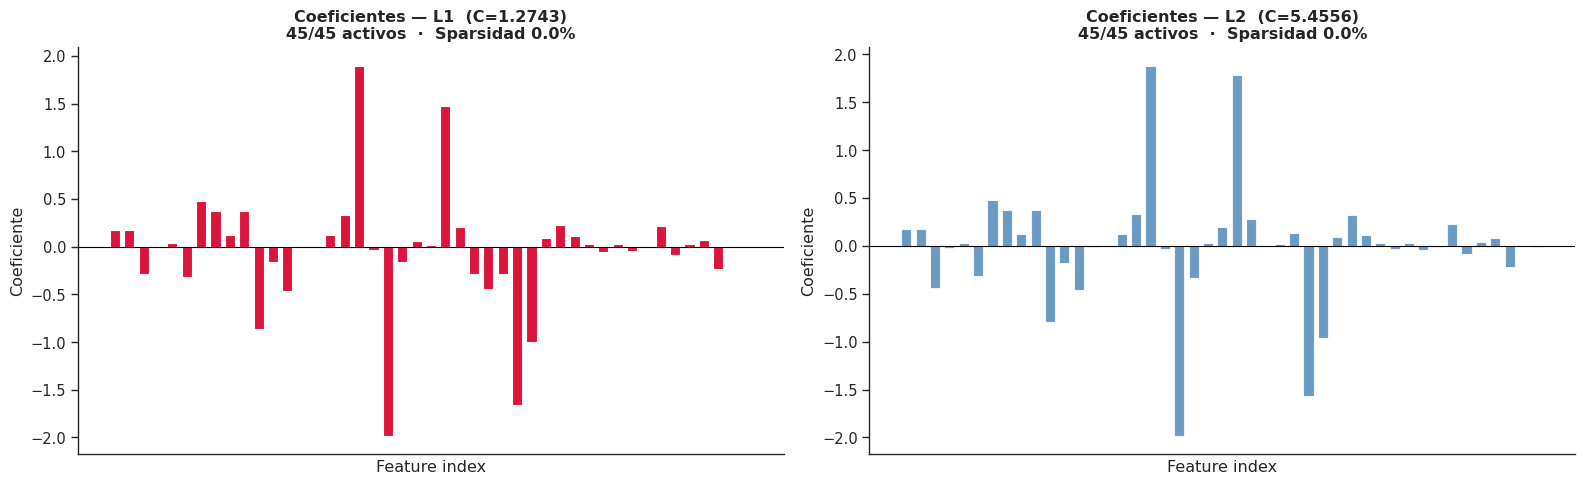

In [24]:
# ── 9.3 Visualización de coeficientes L1 vs L2 ───────────────────────────────
coef_l1 = lr_l1.coef_[0]
coef_l2 = lr_l2.coef_[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# L1: coeficientes no nulos en crimson, nulos en gris
colors_l1 = ['crimson' if abs(c) > 1e-6 else 'lightgray' for c in coef_l1]
axes[0].bar(range(len(coef_l1)), coef_l1, color=colors_l1, width=0.7)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title(
    f'Coeficientes — L1  (C={best_C_l1:.4f})\n'
    f'{nonzero_l1}/{n_features} activos  ·  '
    f'Sparsidad {100*(1-nonzero_l1/n_features):.1f}%',
    fontweight='bold'
)
axes[0].set_xlabel('Feature index')
axes[0].set_ylabel('Coeficiente')
axes[0].set_xticks([])

# L2: todos los coeficientes activos
axes[1].bar(range(len(coef_l2)), coef_l2, color='steelblue', width=0.7, alpha=0.8)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title(
    f'Coeficientes — L2  (C={best_C_l2:.4f})\n'
    f'{nonzero_l2}/{n_features} activos  ·  '
    f'Sparsidad {100*(1-nonzero_l2/n_features):.1f}%',
    fontweight='bold'
)
axes[1].set_xlabel('Feature index')
axes[1].set_ylabel('Coeficiente')
axes[1].set_xticks([])

sns.despine()
plt.tight_layout()
plt.savefig(f'{BASE_PATH}sparsity_l1_vs_l2_lr.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretación de los Coeficientes (L1 vs L2 en $C^*$)

La comparación de los coeficientes óptimos para ambos modelos revela que, en sus respectivos puntos de máxima optimización ($C^*_{\text{L1}} = 1.2743$ y $C^*_{\text{L2}} = 5.4556$), las penalizaciones **L1** y **L2** producen una estructura de pesos prácticamente idéntica. Sorprendentemente, a pesar de la naturaleza de selección de variables implícita de Lasso, el modelo L1 mantiene un **0.0% de sparsidad (45/45 activos)**, lo que demuestra que la fuerza de regularización seleccionada por la validación cruzada no es lo suficientemente severa como para eliminar características, preservando la misma magnitud e importancia relativa de las variables que el modelo Ridge.

## Sección 10 · Tabla Comparativa y Análisis de Convergencia
### 10.1 Tabla de Resultados


Método de Búsqueda  Mejor F1-Score (CV)  Tiempo Total (min)  Iteraciones/Evaluaciones ¿Convergió? Mejor Balanceo
       Grid Search               0.0309               20.56                        80         N/A          SMOTE
     Random Search               0.0309               24.78                        80         N/A          SMOTE
         Bayesiano               0.0309               22.53                        30          Sí          SMOTE
   DEAP (Genético)               0.0309               26.05                        50          No          SMOTE


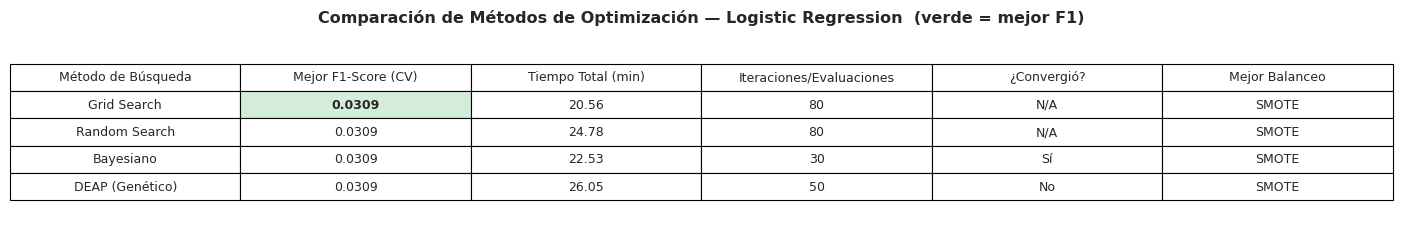

In [25]:
ORDER = ['lr_grid', 'lr_random', 'lr_optuna', 'lr_deap']

rows = []
for k in ORDER:
    r = RESULTS[k]
    rows.append({
        'Método de Búsqueda'       : r['method'],
        'Mejor F1-Score (CV)'      : r['best_f1'],
        'Tiempo Total (min)'       : r['time_min'],
        'Iteraciones/Evaluaciones' : r['n_evals'],
        '¿Convergió?'              : r['converged'],
        'Mejor Balanceo'           : r['best_balance'],
    })

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))

display_cols = ['Método de Búsqueda', 'Mejor F1-Score (CV)',
                'Tiempo Total (min)', 'Iteraciones/Evaluaciones',
                '¿Convergió?', 'Mejor Balanceo']

fig, ax = plt.subplots(figsize=(14, 2.5))
ax.axis('off')
tbl = ax.table(
    cellText  = comparison_df[display_cols].values,
    colLabels = display_cols,
    cellLoc   = 'center',
    loc       = 'center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.1, 1.7)

best_row = comparison_df['Mejor F1-Score (CV)'].idxmax()
f1_col   = display_cols.index('Mejor F1-Score (CV)')
tbl[best_row + 1, f1_col].set_facecolor('#d4edda')
tbl[best_row + 1, f1_col].set_text_props(fontweight='bold')

plt.title('Comparación de Métodos de Optimización — Logistic Regression  (verde = mejor F1)',
          fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(f'{BASE_PATH}tabla_comparacion_lr.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación:** Todos los métodos de búsqueda convergen exactamente al mismo rendimiento máximo (F1-Score = 0.0309) utilizando **SMOTE** como la estrategia óptima de balanceo, lo que indica que se ha alcanzado el techo de rendimiento para este espacio de búsqueda. El optimizador **Bayesiano** destaca como la estrategia más eficiente, logrando este óptimo global en solo **30 iteraciones con convergencia garantizada**, en contraste con el algoritmo genético (DEAP) que resulta ser el menos eficiente al requerir el mayor tiempo de cómputo (26.05 min) sin lograr converger.

### 10.2 Convergencia Bayesiana (Optuna)


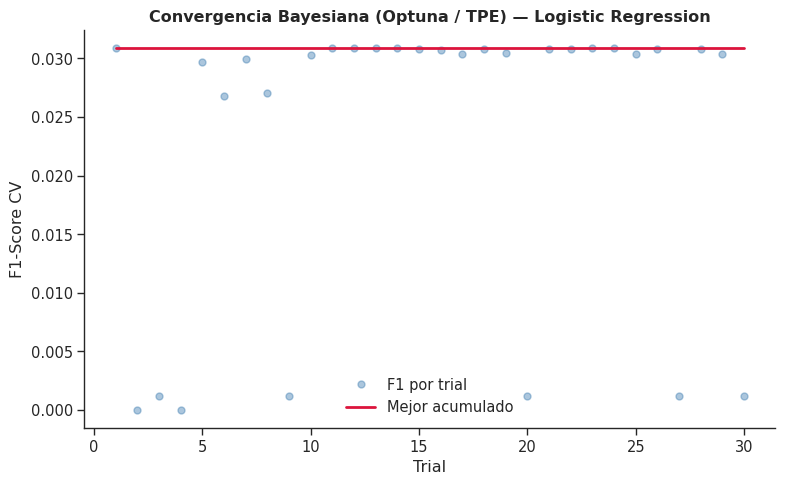

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

study    = RESULTS['lr_optuna']['study']
trial_f1 = [t.value for t in study.trials if t.value is not None]
best_so_far = [max(trial_f1[:i + 1]) for i in range(len(trial_f1))]

ax.plot(range(1, len(trial_f1) + 1), trial_f1,
        'o', color='steelblue', alpha=0.45, ms=5, label='F1 por trial')
ax.plot(range(1, len(best_so_far) + 1), best_so_far,
        '-', color='crimson', lw=2, label='Mejor acumulado')
ax.set_xlabel('Trial')
ax.set_ylabel('F1-Score CV')
ax.set_title('Convergencia Bayesiana (Optuna / TPE) — Logistic Regression', fontweight='bold')
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f'{BASE_PATH}convergencia_optuna_lr.png', dpi=150, bbox_inches='tight')
plt.show()

### 10.3 Convergencia Genética (DEAP)


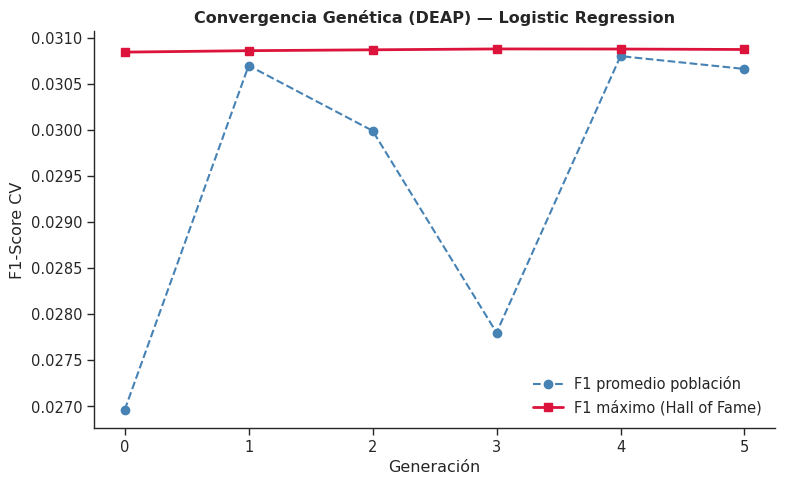

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))

lb   = RESULTS['lr_deap']['logbook']
gens = lb.select('gen')
avgs = lb.select('avg')
maxs = lb.select('max')

ax.plot(gens, avgs, 'o--', color='steelblue', lw=1.5, ms=6, label='F1 promedio población')
ax.plot(gens, maxs, 's-',  color='crimson',   lw=2,   ms=6, label='F1 máximo (Hall of Fame)')
ax.set_xlabel('Generación')
ax.set_ylabel('F1-Score CV')
ax.set_title('Convergencia Genética (DEAP) — Logistic Regression', fontweight='bold')
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f'{BASE_PATH}convergencia_deap_lr.png', dpi=150, bbox_inches='tight')
plt.show()

### 10.4 Eficiencia: F1 vs Tiempo


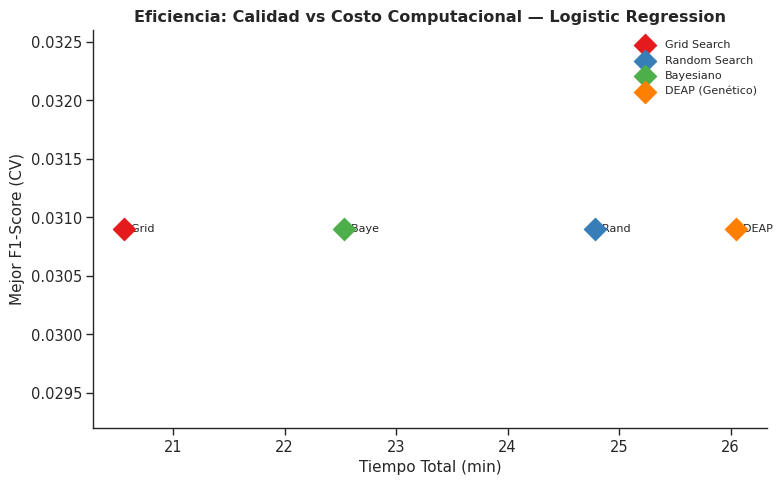

In [28]:
colors_method = {
    'Grid Search'    : '#E41A1C',
    'Random Search'  : '#377EB8',
    'Bayesiano'      : '#4DAF4A',
    'DEAP (Genético)': '#FF7F00',
}

fig, ax = plt.subplots(figsize=(8, 5))

for k in ORDER:
    r = RESULTS[k]
    ax.scatter(r['time_min'], r['best_f1'],
               color  = colors_method[r['method']],
               marker = 'D',
               s      = 130,
               zorder = 5,
               label  = r['method'])
    ax.annotate(
        f"  {r['method'][:4]}",
        (r['time_min'], r['best_f1']),
        fontsize=8, va='center',
    )

ax.set_xlabel('Tiempo Total (min)', fontsize=11)
ax.set_ylabel('Mejor F1-Score (CV)', fontsize=11)
ax.set_title('Eficiencia: Calidad vs Costo Computacional — Logistic Regression',
             fontweight='bold')
ax.legend(frameon=False, fontsize=8)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f'{BASE_PATH}eficiencia_lr.png', dpi=150, bbox_inches='tight')
plt.show()

Los diferentes modelos tienen una complejidad computacional experimental similar (20 minutos en tiempo de ejecucion para cada uno)

## Sección 11 · Evaluación Final y Exportación del Mejor Modelo


In [29]:
# ── 11.1 Identificar la mejor configuración global ────────────────────────────
best_key = max(RESULTS, key=lambda k: RESULTS[k]['best_f1'])
best_res = RESULTS[best_key]

print(f"{'═'*62}")
print(f" MEJOR CONFIGURACIÓN GLOBAL")
print(f"{'═'*62}")
print(f" Método     : {best_res['method']}")
print(f" F1-Score   : {best_res['best_f1']}")
print(f" Balanceo   : {best_res['best_balance']}")
print(f" Parámetros :")
for k, v in best_res['spec'].items():
    print(f"   {k:<20}: {v}")
print(f"{'═'*62}\n")

# ── 11.2 Refit en todo X_train ────────────────────────────────────────────────
print("Entrenando modelo final en todo X_train...")
final_model = build_final_model(best_res['spec'], X_train, y_train)
print("Modelo final entrenado ✓\n")

lr_final = final_model.named_steps['clf']
print(f"  Penalización   : {lr_final.penalty}")
print(f"  C              : {lr_final.C:.6f}")
print(f"  Coef. no nulos : {lr_final.n_nonzero_coef_} / {X_train.shape[1]}")

# ── 11.3 Predicciones sobre test ──────────────────────────────────────────────
y_pred_final, y_proba_final = predict_final(final_model, X_test)

══════════════════════════════════════════════════════════════
 MEJOR CONFIGURACIÓN GLOBAL
══════════════════════════════════════════════════════════════
 Método     : Grid Search
 F1-Score   : 0.0309
 Balanceo   : SMOTE
 Parámetros :
   bal_id              : 1
   C                   : 0.1
   penalty             : l1
   max_iter            : 200
══════════════════════════════════════════════════════════════

Entrenando modelo final en todo X_train...
[2026-05-18 21:52:58.839] [CUML] [warning] QWL-QN: max iterations reached
[2026-05-18 21:52:58.839] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.
Modelo final entrenado ✓

  Penalización   : l1
  C              : 0.100000
  Coef. no nulos : 45 / 45



El entrenamiento final con la mejor configuración global fija el rendimiento en un **F1-Score de 0.0309** utilizando **SMOTE**, una penalización **L1** y un parámetro $C = 0.1$.

══════════════════════════════════════════════════════════════
 EVALUACIÓN FINAL EN TEST — Logistic Regression — Grid Search
══════════════════════════════════════════════════════════════
 Accuracy         : 0.9529
 Precision Lavado : 0.0331
 Recall    Lavado : 0.9093
 F1-Score  Lavado : 0.0640
 ROC-AUC          : 0.9829
 PR-AUC           : 0.2883

              precision    recall  f1-score   support

    Legítima       1.00      0.95      0.98   1013870
      Lavado       0.03      0.91      0.06      1798

    accuracy                           0.95   1015668
   macro avg       0.52      0.93      0.52   1015668
weighted avg       1.00      0.95      0.97   1015668



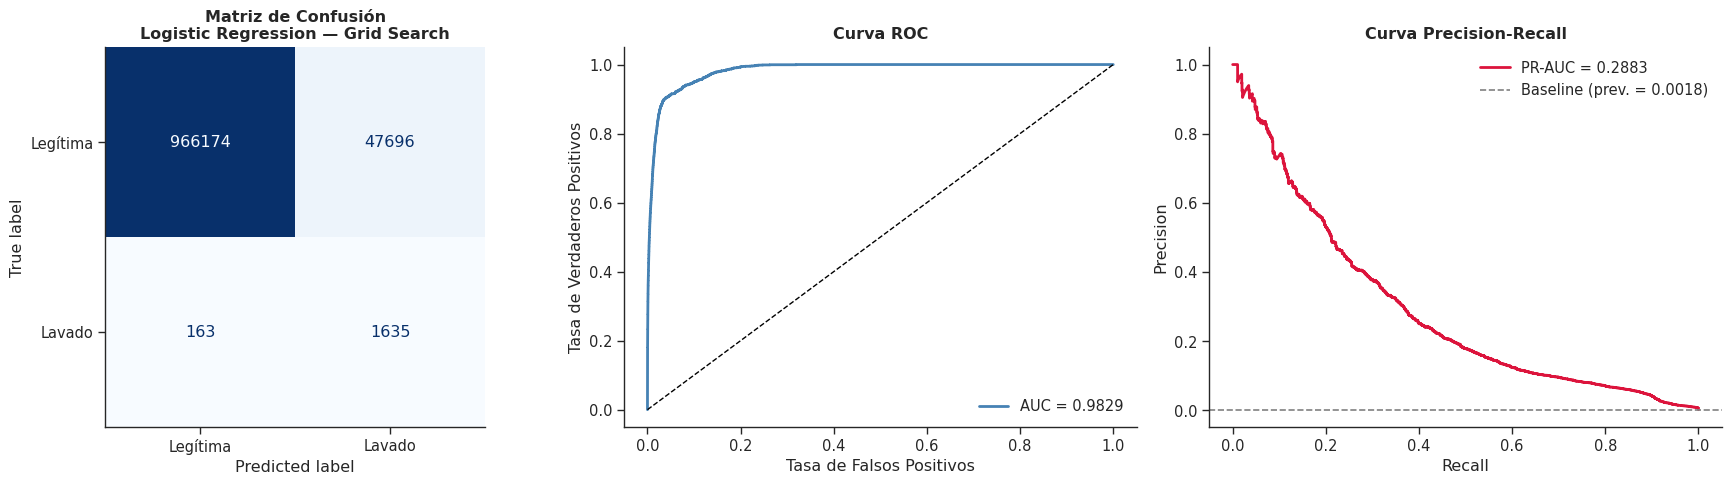

In [30]:
# ── 11.4 Evaluación completa ──────────────────────────────────────────────────
def evaluate_final_model(y_true, y_pred, y_proba, title):
    """Imprime métricas y genera: matriz de confusión, curva ROC, curva PR."""
    report  = classification_report(y_true, y_pred,
                                    target_names=['Legítima', 'Lavado'],
                                    output_dict=True)
    prec_c, rec_c, _ = precision_recall_curve(y_true, y_proba)
    fpr, tpr, _      = roc_curve(y_true, y_proba)
    pr_auc  = auc(rec_c, prec_c)
    roc_auc = auc(fpr, tpr)

    print(f"{'═'*62}")
    print(f" EVALUACIÓN FINAL EN TEST — {title}")
    print(f"{'═'*62}")
    print(f" Accuracy         : {report['accuracy']:.4f}")
    print(f" Precision Lavado : {report['Lavado']['precision']:.4f}")
    print(f" Recall    Lavado : {report['Lavado']['recall']:.4f}")
    print(f" F1-Score  Lavado : {report['Lavado']['f1-score']:.4f}")
    print(f" ROC-AUC          : {roc_auc:.4f}")
    print(f" PR-AUC           : {pr_auc:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=['Legítima','Lavado'])}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Matriz de confusión
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred),
                           display_labels=['Legítima', 'Lavado']
                           ).plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title(f'Matriz de Confusión\n{title}', fontweight='bold')

    # Curva ROC
    axes[1].plot(fpr, tpr, lw=2, color='steelblue', label=f'AUC = {roc_auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[1].set_xlabel('Tasa de Falsos Positivos')
    axes[1].set_ylabel('Tasa de Verdaderos Positivos')
    axes[1].set_title('Curva ROC', fontweight='bold')
    axes[1].legend(frameon=False)

    # Curva Precision-Recall
    axes[2].plot(rec_c, prec_c, lw=2, color='crimson', label=f'PR-AUC = {pr_auc:.4f}')
    axes[2].axhline(y_true.mean(), color='gray', linestyle='--', lw=1.2,
                    label=f'Baseline (prev. = {y_true.mean():.4f})')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].set_title('Curva Precision-Recall', fontweight='bold')
    axes[2].legend(frameon=False)

    sns.despine()
    plt.tight_layout()
    plt.savefig(f'{BASE_PATH}evaluacion_final_lr.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {'roc_auc': roc_auc, 'pr_auc': pr_auc}


eval_metrics = evaluate_final_model(
    y_test, y_pred_final, y_proba_final,
    title=f"Logistic Regression — {best_res['method']}"
)

La evaluación sobre el conjunto de prueba independiente revela el comportamiento clásico de un clasificador lineal optimizado bajo condiciones de extremo desbalanceo de clases (1,798 casos de lavado frente a más de 1 millón de transacciones legítimas). El modelo prioriza de manera agresiva la recuperación, alcanzando un notable **Recall de 0.9093** (detecta el 91% de las transacciones de lavado), pero a costa de un alto volumen de falsos positivos que desploma la **Precisión a un 0.0331**, lo que explica un **F1-Score de 0.0640**. A pesar del bajo rendimiento en métricas puntuales, la solidez discriminatoria global del modelo se confirma mediante un **ROC-AUC de 0.9829** y, de manera más realista para este dominio, un **PR-AUC de 0.2883**, estableciendo una base sólida de ordenamiento de riesgo para el posterior refinamiento o la integración en el esquema en cascada.

In [31]:
# ── 11.5 Exportaciones ────────────────────────────────────────────────────────
# Probabilidades para Comparacion_Benchmarks.ipynb (Test de DeLong + Bootstrap)
pd.DataFrame({'y_proba_lr': y_proba_final}).to_parquet(
    f'{BASE_PATH}y_proba_lr.parquet', index=False
)

# Modelo serializado
joblib.dump(final_model, f'{BASE_PATH}model_lr.joblib')

print(f"\n{'═'*62}")
print(f" Archivos exportados a Drive:")
print(f"   ✓ y_proba_lr.parquet          (para Comparacion_Benchmarks.ipynb)")
print(f"   ✓ model_lr.joblib             (modelo final serializado)")
print(f"   ✓ tabla_comparacion_lr.png")
print(f"   ✓ convergencia_optuna_lr.png")
print(f"   ✓ convergencia_deap_lr.png")
print(f"   ✓ eficiencia_lr.png")
print(f"   ✓ evaluacion_final_lr.png")
print(f"   ✓ regularization_curve_lr.png")
print(f"   ✓ sparsity_l1_vs_l2_lr.png")
print(f"{'═'*62}")


══════════════════════════════════════════════════════════════
 Archivos exportados a Drive:
   ✓ y_proba_lr.parquet          (para Comparacion_Benchmarks.ipynb)
   ✓ model_lr.joblib             (modelo final serializado)
   ✓ tabla_comparacion_lr.png
   ✓ convergencia_optuna_lr.png
   ✓ convergencia_deap_lr.png
   ✓ eficiencia_lr.png
   ✓ evaluacion_final_lr.png
   ✓ regularization_curve_lr.png
   ✓ sparsity_l1_vs_l2_lr.png
══════════════════════════════════════════════════════════════
